# ECG Arrhythmia Classification — EDA & Baseline

This notebook performs exploratory data analysis and establishes the baseline
machine learning pipeline for ECG arrhythmia classification.

Dataset: MIT-BIH Arrhythmia Database

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames:
        print("   ", filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/aakashshah3799
/kaggle/input/datasets/aakashshah3799/mitbih-mlii-duallead-dataset
    MITBIH_MLII_DualLead_Dataset.csv


In [6]:
dataset_path = "/kaggle/input/datasets/aakashshah3799/mitbih-mlii-duallead-dataset/MITBIH_MLII_DualLead_Dataset.csv"
df = pd.read_csv(dataset_path)

print("Shape:", df.shape)
print("\nColumns:", df.shape[1])
print("\nMissing values:", df.isnull().sum().sum())

Shape: (106870, 404)

Columns: 404

Missing values: 0


In [5]:
df.head()

,Record_ID,MLII_0,MLII_1,MLII_2,MLII_3,MLII_4,MLII_5,MLII_6,MLII_7,MLII_8,...,Lead2_192,Lead2_193,Lead2_194,Lead2_195,Lead2_196,Lead2_197,Lead2_198,Lead2_199,Lead2_200,Label
0,100,961,964,963,962,960,958,959,961,962,...,946,947,946,944,942,940,943,942,942,N
1,100,955,955,955,958,958,957,955,954,954,...,939,940,942,943,944,944,943,947,951,N
2,100,951,955,955,956,953,951,952,953,953,...,949,949,949,948,951,955,957,961,962,N
3,100,954,954,954,956,956,955,955,948,952,...,941,939,942,945,947,943,945,945,949,N
4,100,958,961,961,958,958,957,957,958,958,...,951,953,951,950,949,949,950,953,952,N


In [7]:
df["Label"].value_counts()

Label
N    74766
L     8073
R     7257
V     7123
/     3619
A     2546
F      802
~      577
!      472
"      437
f      260
j      229
x      193
a      150
|      132
E      106
J       83
e       16
Q       15
[        6
]        6
S        2
Name: count, dtype: int64

In [8]:
df["Label"].value_counts(normalize=True) * 100

Label
N    69.959764
L     7.554038
R     6.790493
V     6.665107
/     3.386357
A     2.382334
F     0.750444
~     0.539908
!     0.441658
"     0.408908
f     0.243286
j     0.214279
x     0.180593
a     0.140357
|     0.123515
E     0.099186
J     0.077664
e     0.014971
Q     0.014036
[     0.005614
]     0.005614
S     0.001871
Name: proportion, dtype: float64

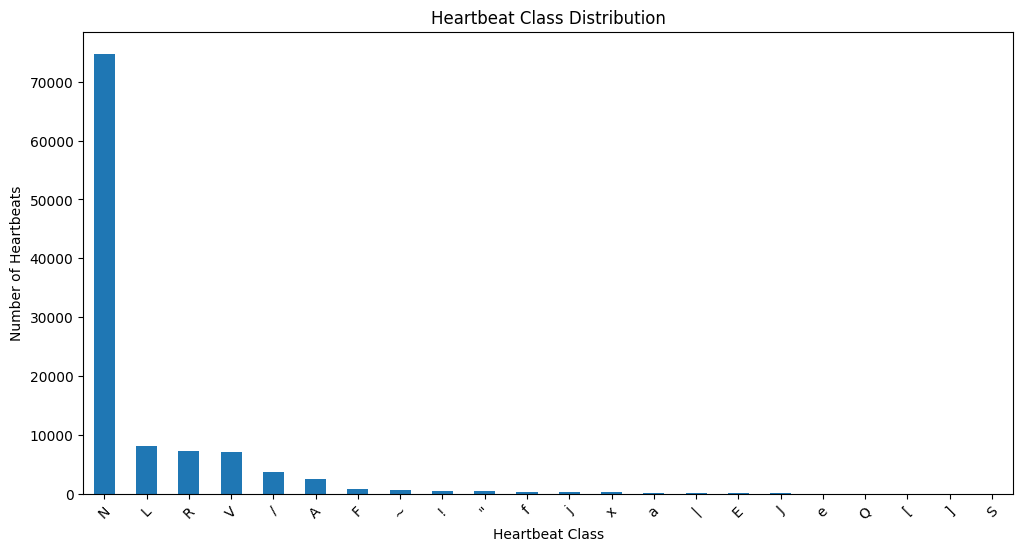

In [9]:
class_counts = df["Label"].value_counts()

plt.figure(figsize=(12, 6))
class_counts.plot(kind="bar")
plt.xlabel("Heartbeat Class")
plt.ylabel("Number of Heartbeats")
plt.title("Heartbeat Class Distribution")
plt.xticks(rotation=45)
plt.show()

In [10]:
record_counts = df["Record_ID"].value_counts().sort_index()

print(record_counts)

Record_ID
100    2271
101    1872
103    2090
105    2690
106    2056
107    2138
108    1822
109    2533
111    2132
112    2549
113    1794
114    1887
115    1960
116    2419
117    1537
118    2299
119    1991
121    1875
122    2476
123    1517
124    1621
200    2643
201    2004
202    2138
203    3061
205    2659
207    2360
208    2985
209    3031
210    2666
212    2761
213    3249
214    2271
215    3395
217    2213
219    2291
220    2050
221    2439
222    2497
223    2615
228    2100
230    2258
231    2000
232    1815
233    3079
234    2761
Name: count, dtype: int64


In [11]:
print("Number of records:", df["Record_ID"].nunique())
print("Average heartbeats per record:", record_counts.mean())
print("Minimum:", record_counts.min())
print("Maximum:", record_counts.max())

Number of records: 46
Average heartbeats per record: 2323.2608695652175
Minimum: 1517
Maximum: 3395


In [12]:
record_class_counts = pd.crosstab(
    df["Record_ID"],
    df["Label"]
)

record_class_counts.head()

Label,!,"""",/,A,E,F,J,L,N,Q,...,V,[,],a,e,f,j,x,|,~
Record_ID,,,,,,,,,,,,,,,,,,,,,
100,0,0,0,33,0,0,0,0,2237,0,...,1,0,0,0,0,0,0,0,0,0
101,0,0,0,3,0,0,0,0,1859,2,...,0,0,0,0,0,0,0,0,4,4
103,0,0,0,2,0,0,0,0,2082,0,...,0,0,0,0,0,0,0,0,0,6
105,0,0,0,0,0,0,0,0,2526,5,...,41,0,0,0,0,0,0,0,30,88
106,0,0,0,0,0,0,0,0,1507,0,...,520,0,0,0,0,0,0,0,0,29


In [13]:
print("Records containing each class:")
print((record_class_counts > 0).sum().sort_values())

Records containing each class:
Label
!     1
]     1
[     1
S     1
f     1
e     1
E     2
/     2
L     4
Q     5
"     5
J     5
x     5
j     5
R     6
a     7
F    17
|    19
A    27
V    35
~    37
N    38
dtype: int64


In [14]:
aami_mapping = {
    "N": "N",
    "L": "N",
    "R": "N",
    "e": "N",
    "j": "N",

    "A": "S",
    "a": "S",
    "J": "S",
    "S": "S",

    "V": "V",
    "E": "V",

    "F": "F",

    "/": "Q",
    "f": "Q",
    "Q": "Q"
}

df["AAMI_Label"] = df["Label"].map(aami_mapping)

In [15]:
print("Original samples:", len(df))
print("Mapped samples:", df["AAMI_Label"].notna().sum())
print("Unmapped samples:", df["AAMI_Label"].isna().sum())

Original samples: 106870
Mapped samples: 105047
Unmapped samples: 1823


In [16]:
df["AAMI_Label"].value_counts(dropna=False)

AAMI_Label
N      90341
V       7229
Q       3894
S       2781
NaN     1823
F        802
Name: count, dtype: int64

In [17]:
df.loc[df["AAMI_Label"].isna(), "Label"].value_counts()

Label
~    577
!    472
"    437
x    193
|    132
[      6
]      6
Name: count, dtype: int64

In [18]:
aami_df = df.dropna(subset=["AAMI_Label"]).copy()

print("AAMI Dataset Shape:", aami_df.shape)

print("\nClass Counts:")
print(aami_df["AAMI_Label"].value_counts())

print("\nClass Percentages:")
print(aami_df["AAMI_Label"].value_counts(normalize=True) * 100)

AAMI Dataset Shape: (105047, 405)

Class Counts:
AAMI_Label
N    90341
V     7229
Q     3894
S     2781
F      802
Name: count, dtype: int64

Class Percentages:
AAMI_Label
N    86.000552
V     6.881682
Q     3.706912
S     2.647386
F     0.763468
Name: proportion, dtype: float64


In [19]:
aami_record_classes = pd.crosstab(
    aami_df["Record_ID"],
    aami_df["AAMI_Label"]
)

print(aami_record_classes)

AAMI_Label    F     N     Q     S    V
Record_ID                             
100           0  2237     0    33    1
101           0  1859     2     3    0
103           0  2082     0     2    0
105           0  2526     5     0   41
106           0  1507     0     0  520
107           0     0  2077     0   59
108           2  1739     0     4   17
109           2  2491     0     0   38
111           0  2123     0     0    1
112           0  2537     0     2    0
113           0  1788     0     6    0
114           4  1820     0    12   43
115           0  1952     0     0    0
116           0  2301     0     1  109
117           0  1533     0     1    0
118           0  2165     0    96   16
119           0  1543     0     0  444
121           0  1861     0     1    1
122           0  2474     0     0    0
123           0  1514     0     0    3
124           5  1536     0    31   47
200           2  1742     0    30  826
201           2  1635     0   128  198
202           1  2061    

In [20]:
print("Records containing each AAMI class:")
print((aami_record_classes > 0).sum().sort_values())

Records containing each AAMI class:
AAMI_Label
Q     7
F    17
S    32
V    35
N    45
dtype: int64


In [21]:
ecg_features = [
    col for col in aami_df.columns
    if col.startswith("MLII_") or col.startswith("Lead2_")
]

constant_features = [
    col for col in ecg_features
    if aami_df[col].nunique() <= 1
]

print("Total ECG features:", len(ecg_features))
print("Constant features:", len(constant_features))

if constant_features:
    print(constant_features)

Total ECG features: 402
Constant features: 0


In [22]:
print("Minimum ECG value:", aami_df[ecg_features].min().min())
print("Maximum ECG value:", aami_df[ecg_features].max().max())

Minimum ECG value: 0
Maximum ECG value: 2047


In [23]:
X = aami_df[ecg_features]
y = aami_df["AAMI_Label"]
groups = aami_df["Record_ID"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Groups:", groups.nunique())

X shape: (105047, 402)
y shape: (105047,)
Groups: 46


In [24]:
print(y.value_counts())

AAMI_Label
N    90341
V     7229
Q     3894
S     2781
F      802
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import StratifiedGroupKFold

print("StratifiedGroupKFold is available!")

StratifiedGroupKFold is available!


In [26]:
from sklearn.model_selection import StratifiedGroupKFold

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X, y, groups=groups), start=1
):
    print(f"Fold {fold}")
    print("Train:", len(train_idx))
    print("Validation:", len(val_idx))
    print()

Fold 1
Train: 80543
Validation: 24504

Fold 2
Train: 80984
Validation: 24063

Fold 3
Train: 86520
Validation: 18527

Fold 4
Train: 86508
Validation: 18539

Fold 5
Train: 85633
Validation: 19414



In [27]:
for fold, (train_idx, val_idx) in enumerate(
    cv.split(X, y, groups=groups), start=1
):
    
    train_records = set(groups.iloc[train_idx])
    val_records = set(groups.iloc[val_idx])
    
    overlap = train_records.intersection(val_records)
    
    print(f"Fold {fold}:")
    print("  Training records:", len(train_records))
    print("  Validation records:", len(val_records))
    print("  Overlapping records:", len(overlap))

Fold 1:
  Training records: 36
  Validation records: 10
  Overlapping records: 0
Fold 2:
  Training records: 35
  Validation records: 11
  Overlapping records: 0
Fold 3:
  Training records: 38
  Validation records: 8
  Overlapping records: 0
Fold 4:
  Training records: 38
  Validation records: 8
  Overlapping records: 0
Fold 5:
  Training records: 37
  Validation records: 9
  Overlapping records: 0


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print(rf_baseline)

RandomForestClassifier(n_jobs=-1, random_state=42)


In [29]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

baseline_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X, y, groups=groups), start=1
):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    rf_baseline.fit(X_train, y_train)
    y_pred = rf_baseline.predict(X_val)

    baseline_results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_val, y_pred),
        "Macro_F1": f1_score(y_val, y_pred, average="macro", zero_division=0)
    })

baseline_results = pd.DataFrame(baseline_results)

baseline_results

,Fold,Accuracy,Balanced_Accuracy,Macro_F1
0,1,0.780118,0.390881,0.288755
1,2,0.888252,0.500180,0.520171
2,3,0.776003,0.319447,0.282344
3,4,0.827661,0.334326,0.261237
4,5,0.963274,0.297370,0.347027


In [30]:
print("Mean Accuracy:", baseline_results["Accuracy"].mean())
print("Mean Balanced Accuracy:", baseline_results["Balanced_Accuracy"].mean())
print("Mean Macro F1:", baseline_results["Macro_F1"].mean())

Mean Accuracy: 0.8470612657476941
Mean Balanced Accuracy: 0.36844085566930546
Mean Macro F1: 0.33990689105154653


In [31]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

print("Imbalanced-learn is ready!")

Imbalanced-learn is ready!


# I just trained these class balancing at first just to see what is the result. It has no meaning in the result yet. We can ignore it also for now.

In [32]:
from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    ADASYN,
    BorderlineSMOTE
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

balancing_methods = {
    "Random Oversampling": RandomOverSampler(
        random_state=42
    ),
    
    "SMOTE": SMOTE(
        random_state=42,
        k_neighbors=3
    ),
    
    "ADASYN": ADASYN(
        random_state=42,
        n_neighbors=3
    ),
    
    "Borderline-SMOTE": BorderlineSMOTE(
        random_state=42,
        k_neighbors=3
    )
}

balancing_results = []

for method_name, sampler in balancing_methods.items():

    print(f"\n===== {method_name} =====")

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X, y, groups=groups), start=1
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        # Balance TRAINING data only
        X_resampled, y_resampled = sampler.fit_resample(
            X_train, y_train
        )

        print(
            f"Fold {fold}: "
            f"{len(X_train)} → {len(X_resampled)} training samples"
        )

        # Fresh RF with identical settings
        rf = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_resampled, y_resampled)

        y_pred = rf.predict(X_val)

        fold_scores.append({
            "Fold": fold,
            "Accuracy": accuracy_score(y_val, y_pred),
            "Balanced_Accuracy": balanced_accuracy_score(
                y_val, y_pred
            ),
            "Macro_F1": f1_score(
                y_val, y_pred,
                average="macro",
                zero_division=0
            )
        })

    fold_scores = pd.DataFrame(fold_scores)

    balancing_results.append({
        "Method": method_name,
        "Accuracy": fold_scores["Accuracy"].mean(),
        "Balanced_Accuracy": fold_scores["Balanced_Accuracy"].mean(),
        "Macro_F1": fold_scores["Macro_F1"].mean()
    })

balancing_results = pd.DataFrame(balancing_results)

balancing_results.sort_values(
    "Macro_F1",
    ascending=False
)



===== Random Oversampling =====
Fold 1: 80543 → 342970 training samples
Fold 2: 80984 → 360175 training samples
Fold 3: 86520 → 377230 training samples
Fold 4: 86508 → 366365 training samples
Fold 5: 85633 → 360080 training samples

===== SMOTE =====
Fold 1: 80543 → 342970 training samples
Fold 2: 80984 → 360175 training samples
Fold 3: 86520 → 377230 training samples
Fold 4: 86508 → 366365 training samples
Fold 5: 85633 → 360080 training samples

===== ADASYN =====
Fold 1: 80543 → 342894 training samples
Fold 2: 80984 → 360221 training samples
Fold 3: 86520 → 377171 training samples
Fold 4: 86508 → 366369 training samples
Fold 5: 85633 → 359985 training samples

===== Borderline-SMOTE =====
Fold 1: 80543 → 342970 training samples
Fold 2: 80984 → 360175 training samples
Fold 3: 86520 → 377230 training samples
Fold 4: 86508 → 366365 training samples
Fold 5: 85633 → 360080 training samples


,Method,Accuracy,Balanced_Accuracy,Macro_F1
1,SMOTE,0.859467,0.391401,0.364422
0,Random Oversampling,0.875302,0.374081,0.359031
3,Borderline-SMOTE,0.875711,0.356960,0.334975
2,ADASYN,0.855619,0.356910,0.329037


In [33]:
balancing_results.sort_values(
    "Macro_F1",
    ascending=False
).reset_index(drop=True)

,Method,Accuracy,Balanced_Accuracy,Macro_F1
0,SMOTE,0.859467,0.391401,0.364422
1,Random Oversampling,0.875302,0.374081,0.359031
2,Borderline-SMOTE,0.875711,0.356960,0.334975
3,ADASYN,0.855619,0.356910,0.329037


In [34]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

print("Preprocessing tools are ready!")

Preprocessing tools are ready!


In [35]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

preprocessing_methods = {
    "No Scaling": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

preprocessing_results = []

for method_name, scaler in preprocessing_methods.items():

    print(f"\n===== {method_name} =====")

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X, y, groups=groups), start=1
    ):

        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        # Fit preprocessing ONLY on training data
        if scaler is not None:
            scaler.fit(X_train)

            X_train_processed = scaler.transform(X_train)
            X_val_processed = scaler.transform(X_val)
        else:
            X_train_processed = X_train
            X_val_processed = X_val

        # Same baseline RF for every preprocessing method
        rf = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train_processed, y_train)

        y_pred = rf.predict(X_val_processed)

        fold_scores.append({
            "Fold": fold,
            "Accuracy": accuracy_score(y_val, y_pred),
            "Balanced_Accuracy": balanced_accuracy_score(
                y_val, y_pred
            ),
            "Macro_F1": f1_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0
            )
        })

    fold_scores = pd.DataFrame(fold_scores)

    preprocessing_results.append({
        "Method": method_name,
        "Accuracy": fold_scores["Accuracy"].mean(),
        "Balanced_Accuracy": fold_scores["Balanced_Accuracy"].mean(),
        "Macro_F1": fold_scores["Macro_F1"].mean()
    })

preprocessing_results = pd.DataFrame(preprocessing_results)

preprocessing_results.sort_values(
    "Macro_F1",
    ascending=False
).reset_index(drop=True)


===== No Scaling =====

===== StandardScaler =====

===== MinMaxScaler =====

===== RobustScaler =====


,Method,Accuracy,Balanced_Accuracy,Macro_F1
0,No Scaling,0.847061,0.368441,0.339907
1,RobustScaler,0.846935,0.368381,0.339809
2,StandardScaler,0.847043,0.368498,0.339335
3,MinMaxScaler,0.847042,0.368357,0.339274
